In [1]:
%%capture
%pip install qldpc
%pip install matplotlib
%pip install tqec

# Decoding TQEC Circuits

[TQEC](https://github.com/tqec/tqec) compiles lattice surgery operations into surface-code-protected physical circuits. This notebook demonstrates using a qLDPC decoder to decode circuits compiled and simulated by TQEC. This notebook is adapted from the [TQEC notebooks](https://github.com/tqec/tqec/tree/main/docs/gallery).

## Construction

`tqec` provides builtin functions for constructing some example computations. You can also define your own lattice surgery operations using `tqec.BlockGraph`.

In [2]:
from tqec import Basis
from tqec.gallery import memory, stability, move_rotation, cz, cnot, three_cnots, steane_encoding

block_graph = cnot(Basis.Z)
block_graph.view_as_html()

We can use the `find_correlation_surfaces()` method to identify a generating set of correlation surfaces (observables), and then visualize them using the `view_as_html()` method. We show one of them below.

In [3]:
correlation_surfaces = block_graph.find_correlation_surfaces()
block_graph.view_as_html(
    pop_faces_at_directions=("-Y",),
    show_correlation_surface=correlation_surfaces[0],
)

## Simulation

Here we simulate all observables under uniform depolarizing noise model using qLDPC's decoders. TQEC's `start_simulation_using_sinter` is a wrapper around its compiler and `sinter`, so it accepts compilation arguments and `sinter`'s simulation arguments. Arguments like `save_resume_filepath` may come in handy when the simulation is computationally intensive.

In [ ]:
import numpy
import sinter
from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter

from qldpc import decoders

physical_error_rates = list(numpy.logspace(-4, -2, 5))
distances = list(range(3, 8, 2))


def simulate(decoders: dict[str, sinter.Decoder]) -> list[list[list[sinter.TaskStats]]]:
    # TQEC's `start_simulation_using_sinter` does not support assigning decoders based
    # on the distance, so for sliding window decoders, we need to run the simulations
    # individually for each code distance and assign the corresponding decoder.
    return [
        start_simulation_using_sinter(
            block_graph,
            [d // 2],
            physical_error_rates,
            NoiseModel.uniform_depolarizing,
            manhattan_radius=2,
            observables=correlation_surfaces,
            max_shots=100_000,
            max_errors=500,
            decoders=[f"{d=}"],
            custom_decoders=decoders,
            print_progress=True,
        )
        for d in distances
    ]

In [ ]:
# Regular decoders don't need to be defined for each distance.
# Here, it's for code reuse with sliding window decoders later
custom_decoders = {f"{d=}": decoders.SinterDecoder(with_MWPM=True) for d in distances}

mwpm_stats = simulate(custom_decoders)

## Plotting
We plot the logical error rate of each observable separately. Note that since we simulated each distance separately, in the for-loop below, we rearrange them to be grouped by the observables.

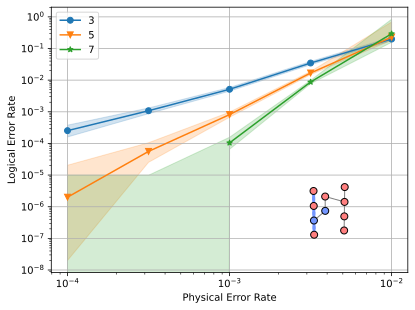

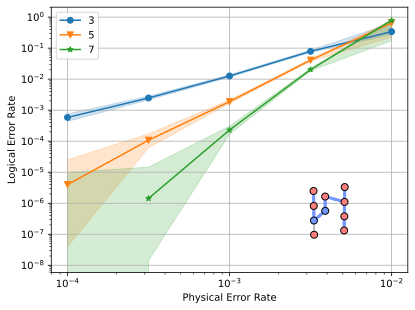

In [9]:
import matplotlib.pyplot as plt
import sinter
from tqec.simulation.plotting.inset import plot_observable_as_inset


zx_graph = block_graph.to_zx_graph()  # for highlighting the correlation surfaces in the ZX diagram


def plot(stats: list[list[list[sinter.TaskStats]]]):
    for i, stat in enumerate(zip(*stats)):
        _, ax = plt.subplots()
        sinter.plot_error_rate(
            ax=ax,
            stats=sum(stat, []),
            x_func=lambda s: s.json_metadata["p"],
            failure_units_per_shot_func=lambda s: s.json_metadata["d"],
            group_func=lambda s: s.json_metadata["d"],
        )
        plot_observable_as_inset(ax, zx_graph, correlation_surfaces[i])
        ax.grid(axis="both")
        ax.legend()
        ax.loglog()
        ax.set_xlabel("Physical Error Rate")
        ax.set_ylabel("Logical Error Rate")

plot(mwpm_stats)

## Sliding Window Decoding

Now we switch to sliding window decoders.

In [ ]:
# We define the sliding window decoder for each code distance
custom_decoders = {
    f"{d=}": decoders.SlidingWindowDecoder(
        d,
        d // 2,
        with_MWPM=True,
    )
    for d in distances
}

sliding_window_mwpm_stats = simulate(custom_decoders)

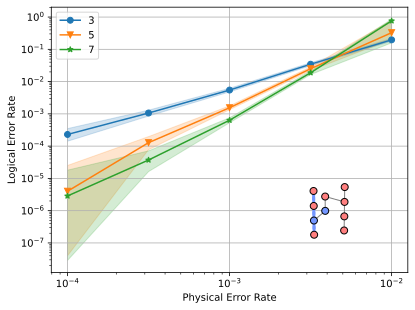

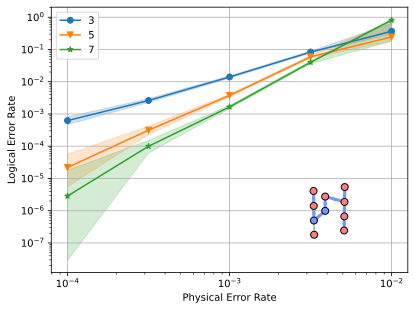

In [8]:
plot(sliding_window_mwpm_stats)